# Stage 1 — Local Train

Train a YOLO model to detect license plates. The goal is a working training
pipeline, not accuracy.

## Environment

In [1]:
import sys
from pathlib import Path

import torch
import ultralytics

# Repo root, so paths do not depend on the notebook's working directory.
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

print("python     ", sys.version.split()[0])
print("torch      ", torch.__version__)
print("ultralytics", ultralytics.__version__)
print("cuda       ", torch.cuda.is_available())

python      3.12.10
torch       2.13.0+cpu
ultralytics 8.4.116
cuda        False


## Data summary

Inspect the raw dataset before training. Ultralytics accepts a mismatched
directory without complaint, so orphans and malformed labels have to be
caught here.

In [2]:
from src.data_loader import summarize

stats = summarize(RAW)
for key, value in stats.items():
    print(f"{key:22} {value}")

pairs                  556
orphan_images          []
orphan_labels          []
boxes_total            574
boxes_per_image_min    1
boxes_per_image_max    3
boxes_per_image_mean   1.03
images_without_boxes   0
class_counts           {'0': 574}
suffixes               {'.jpeg': 543, '.png': 13}
malformed              []


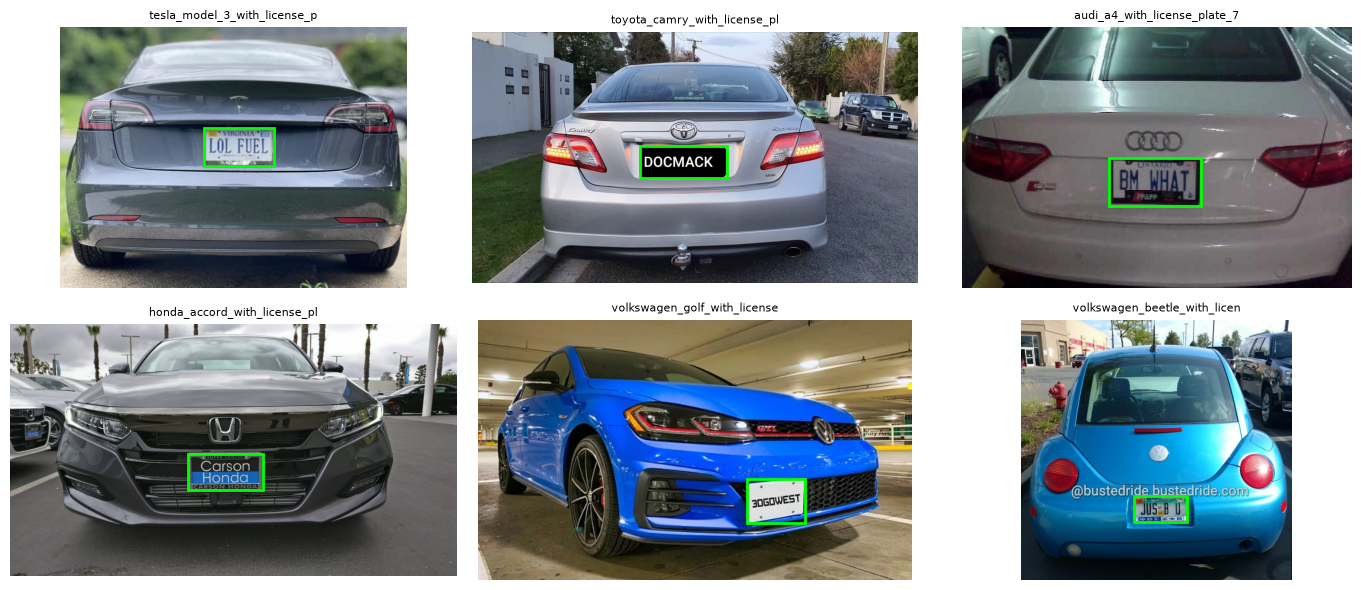

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

from src.data_loader import find_pairs


def show_sample(pairs, n=6, seed=0):
    """Draw label boxes on a few images to confirm the annotations line up."""
    import random

    sample = random.Random(seed).sample(pairs, n)
    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    for ax, (img_path, lbl_path) in zip(axes.ravel(), sample):
        img = Image.open(img_path)
        ax.imshow(img)
        w, h = img.size
        for line in lbl_path.read_text().splitlines():
            if not line.strip():
                continue
            _, cx, cy, bw, bh = (float(v) for v in line.split())
            # YOLO stores normalised centre + size; matplotlib wants corners.
            ax.add_patch(
                plt.Rectangle(
                    ((cx - bw / 2) * w, (cy - bh / 2) * h),
                    bw * w,
                    bh * h,
                    fill=False,
                    edgecolor="lime",
                    linewidth=2,
                )
            )
        ax.set_title(img_path.stem[:28], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


pairs, _, _ = find_pairs(RAW)
show_sample(pairs)

## Split

80/20 train/val, seeded so the split is reproducible. `LIMIT` caps the number
of pairs — training is CPU-only here, so start small and raise it once the
pipeline runs end to end.

In [4]:
from src.data_loader import build_split, verify_split

LIMIT = None  # e.g. 200 for a fast smoke run; None uses all pairs

print(build_split(RAW, PROCESSED, val_fraction=0.2, limit=LIMIT, seed=0))
print(verify_split(PROCESSED))

{'train': 445, 'val': 111, 'orphan_images': 0, 'orphan_labels': 0}
{'train': 445, 'val': 111}


## Dataset descriptor

Single class, read from `classes.txt`.

In [5]:
from src.data_loader import write_data_yaml

names = (RAW / "classes.txt").read_text().split()
data_yaml = write_data_yaml(ROOT / "configs" / "data.yaml", PROCESSED, names)

print(data_yaml)
print(data_yaml.read_text())

C:\Users\simon\OneDrive\Tech\Github\kubeflow-yolo\configs\data.yaml
path: C:/Users/simon/OneDrive/Tech/Github/kubeflow-yolo/data/processed
train: train/images
val: val/images
nc: 1
names: ['car_plate']



## Model

`yolo11n` — the smallest variant, which matters on CPU. Loading pretrained
weights rather than training from scratch: 445 images is far too few to learn
features from nothing.

In [6]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

# Confirm the descriptor resolves and both splits are found before training.
from ultralytics.data.utils import check_det_dataset

checked = check_det_dataset(str(data_yaml))
print({k: checked[k] for k in ("nc", "names", "train", "val")})

{'nc': 1, 'names': {0: 'car_plate'}, 'train': 'C:\\Users\\simon\\OneDrive\\Tech\\Github\\kubeflow-yolo\\data\\processed\\train\\images', 'val': 'C:\\Users\\simon\\OneDrive\\Tech\\Github\\kubeflow-yolo\\data\\processed\\val\\images'}


### Training hyperparameters

Kept in `configs/train.yaml` rather than hardcoded. Small `imgsz` and `epochs`
because this runs on CPU.

In [7]:
import yaml

train_cfg = yaml.safe_load((ROOT / "configs" / "train.yaml").read_text())
train_cfg

{'model': 'yolo11n.pt',
 'epochs': 10,
 'imgsz': 416,
 'batch': 8,
 'device': 'cpu',
 'workers': 4,
 'seed': 0,
 'project': 'runs',
 'name': 'local-train',
 'exist_ok': True}

## Train

A 1-epoch smoke run on 32 images took ~4.5s of training, so 445 images at
10 epochs lands around 11 minutes on this CPU.

`project` is relative to the working directory, so it is made absolute here —
otherwise output lands in `notebooks/runs/`.

In [8]:
import time

cfg = dict(train_cfg)
model_weights = cfg.pop("model")
cfg["project"] = str(ROOT / cfg["project"])

model = YOLO(model_weights)

start = time.time()
results = model.train(data=str(data_yaml), **cfg)
print(f"\nelapsed: {time.time() - start:.0f}s")

Ultralytics 8.4.116  Python-3.12.10 torch-2.13.0+cpu CPU (Intel Core 5 120U)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\simon\OneDrive\Tech\Github\kubeflow-yolo\configs\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=local-train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.1it/s 6.3s

                   all        111        116      0.991      0.936      0.958      0.751


Speed: 0.4ms preprocess, 31.8ms inference, 0.0ms loss, 1.6ms postprocess per image


Results saved to C:\Users\simon\OneDrive\Tech\Github\kubeflow-yolo\runs\local-train



elapsed: 946s


In [9]:
save_dir = Path(results.save_dir)
print(save_dir)

# Final-epoch metrics on the validation split.
for key in ("metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"):
    print(f"{key:24} {results.results_dict[key]:.4f}")

print()
for weight in sorted((save_dir / "weights").glob("*.pt")):
    print(f"{weight.name:10} {weight.stat().st_size / 1e6:.1f} MB")

C:\Users\simon\OneDrive\Tech\Github\kubeflow-yolo\runs\local-train
metrics/precision(B)     0.9909
metrics/recall(B)        0.9355
metrics/mAP50(B)         0.9582
metrics/mAP50-95(B)      0.7506

best.pt    5.4 MB
last.pt    5.4 MB


## Test and evaluate

Reload `best.pt` from disk rather than reusing the in-memory model — this
validates the artifact that would actually be deployed.

In [10]:
best = YOLO(str(save_dir / "weights" / "best.pt"))

metrics = best.val(data=str(data_yaml), imgsz=416, batch=8, device="cpu", plots=False)

print(f"mAP50      {metrics.box.map50:.4f}")
print(f"mAP50-95   {metrics.box.map:.4f}")
print(f"precision  {metrics.box.mp:.4f}")
print(f"recall     {metrics.box.mr:.4f}")

Ultralytics 8.4.116  Python-3.12.10 torch-2.13.0+cpu CPU (Intel Core 5 120U)


YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 391.1345.8 MB/s, size: 157.6 KB)


val: Scanning C:\Users\simon\OneDrive\Tech\Github\kubeflow-yolo\data\processed\val\labels.cache... 111 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 111/111  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 7% ╸─────────── 1/14 1.4s/it 0.4s<17.9s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 92% ━━━━━━━━━━━─ 13/14 1.9it/s 5.7s<0.5s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 2.3it/s 6.2s

                   all        111        116      0.991      0.936      0.958      0.751


Speed: 0.4ms preprocess, 28.7ms inference, 0.0ms loss, 1.5ms postprocess per image


mAP50      0.9582
mAP50-95   0.7506
precision  0.9909
recall     0.9355


### Predictions vs ground truth

Green = label, red = prediction. Recall is below precision, so the interesting
cases are missed plates rather than false alarms.

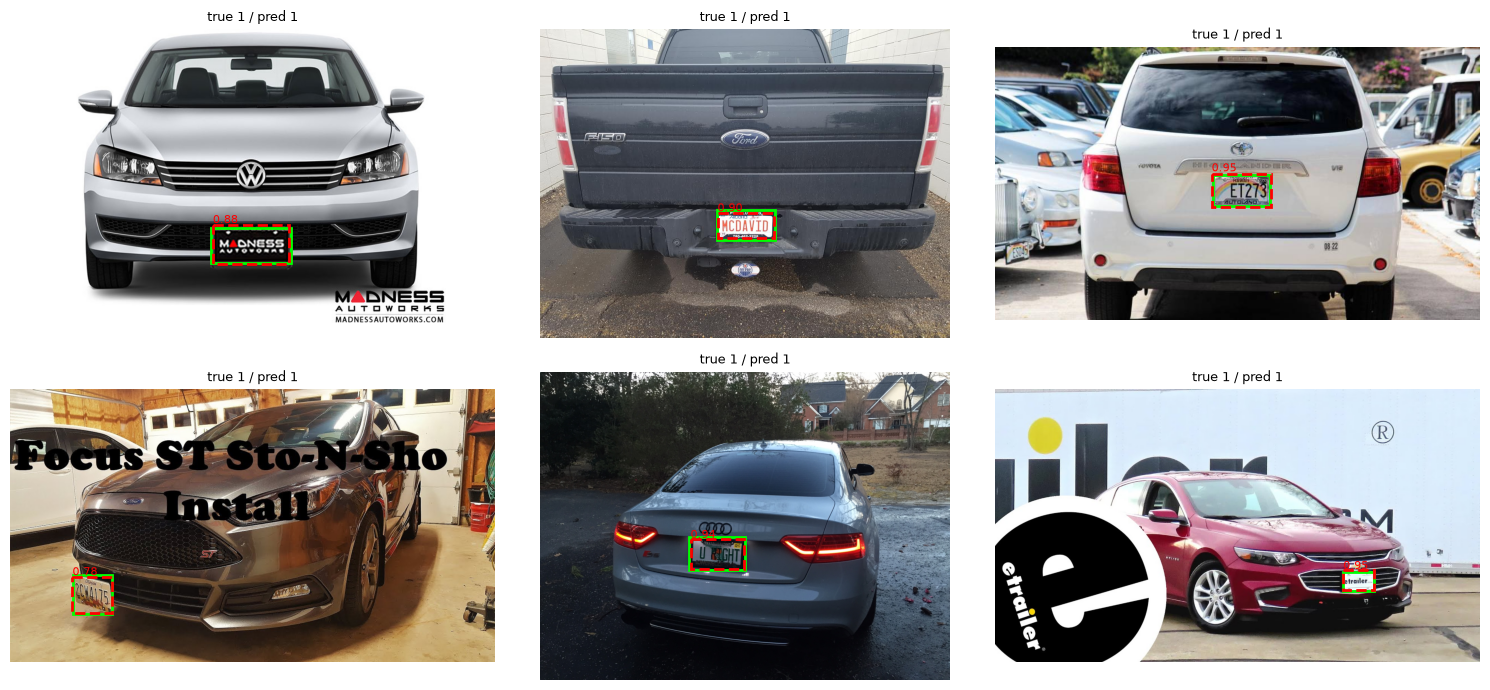

In [11]:
import random


def show_predictions(model, split_dir, n=6, seed=0, conf=0.25):
    """Overlay ground-truth (green) and predicted (red) boxes on val images."""
    images = sorted((split_dir / "images").iterdir())
    sample = random.Random(seed).sample(images, n)

    fig, axes = plt.subplots(2, n // 2, figsize=(15, 7))
    for ax, img_path in zip(axes.ravel(), sample):
        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)

        label_path = split_dir / "labels" / f"{img_path.stem}.txt"
        n_true = 0
        for line in label_path.read_text().splitlines():
            if not line.strip():
                continue
            n_true += 1
            _, cx, cy, bw, bh = (float(v) for v in line.split())
            ax.add_patch(
                plt.Rectangle(
                    ((cx - bw / 2) * w, (cy - bh / 2) * h), bw * w, bh * h,
                    fill=False, edgecolor="lime", linewidth=2,
                )
            )

        result = model.predict(img_path, imgsz=416, conf=conf, device="cpu", verbose=False)[0]
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            ax.add_patch(
                plt.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    fill=False, edgecolor="red", linewidth=2, linestyle="--",
                )
            )
            ax.text(x1, y1 - 4, f"{box.conf.item():.2f}", color="red", fontsize=8)

        ax.set_title(f"true {n_true} / pred {len(result.boxes)}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(best, PROCESSED / "val")

### Where does recall fail?

Recall (0.94) trails precision (0.998), so some plates are missed. Count
detections against labels per image to see whether the misses concentrate in
multi-plate images.

In [12]:
from collections import defaultdict

val_dir = PROCESSED / "val"
by_true_count = defaultdict(lambda: {"images": 0, "true": 0, "pred": 0, "under": 0})

for img_path in sorted((val_dir / "images").iterdir()):
    label_path = val_dir / "labels" / f"{img_path.stem}.txt"
    n_true = len([ln for ln in label_path.read_text().splitlines() if ln.strip()])
    n_pred = len(
        best.predict(img_path, imgsz=416, conf=0.25, device="cpu", verbose=False)[0].boxes
    )

    row = by_true_count[n_true]
    row["images"] += 1
    row["true"] += n_true
    row["pred"] += n_pred
    row["under"] += max(0, n_true - n_pred)

print(f"{'plates/img':>11} {'images':>7} {'labelled':>9} {'detected':>9} {'missed':>7}")
for n_true in sorted(by_true_count):
    r = by_true_count[n_true]
    print(f"{n_true:>11} {r['images']:>7} {r['true']:>9} {r['pred']:>9} {r['under']:>7}")

total_true = sum(r["true"] for r in by_true_count.values())
total_missed = sum(r["under"] for r in by_true_count.values())
print(f"\nmissed {total_missed}/{total_true} plates ({total_missed / total_true:.1%})")

 plates/img  images  labelled  detected  missed
          1     106       106       108       2
          2       5        10         6       4

missed 6/116 plates (5.2%)
